In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy as sp

from bayesian_dro.Bayesian_DRO_continuous import DGP_STD_TRUNCATED_NORMAL


from mis_dro.bayes_conjugates import *
from mis_dro.main import run
from mis_dro.dataset import sample_dgp
from mis_dro.kl_divergence import *

In [2]:
dgp = "normal"
dim = 1
num_likelihood_samples = 10000000
num_observations = 20
likelihood = "normal"
posterior = "normal_gamma"
generator = np.random.default_rng(seed=0)
data = sample_dgp(dgp, num_observations, generator=generator)
prior = default_prior_params(posterior)
post = get_posterior_params(posterior, data, prior)
pp_params = posterior_predictive_params(posterior, post)


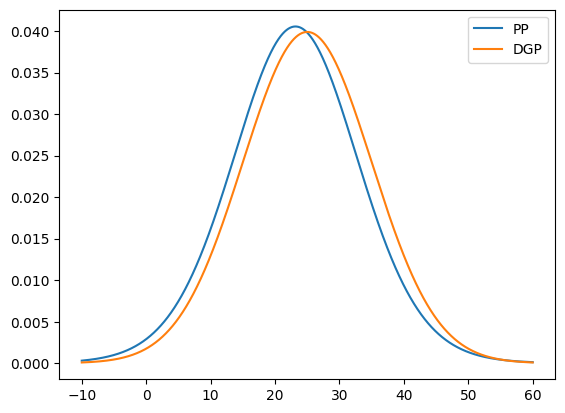

In [3]:
# plot the PDFs of the distributions
mu, scale, df = pp_params[0]
pp_dist = sp.stats.t(df, loc=mu, scale=scale)
dgp_mean = 25
dgp_dist = sp.stats.norm(loc=dgp_mean, scale=DGP_STD_TRUNCATED_NORMAL)
x = np.arange(dgp_mean - 35, dgp_mean + 35, 0.01)
plt.plot(x, pp_dist.pdf(x), label="PP")
plt.plot(x, dgp_dist.pdf(x), label="DGP")
plt.legend()

## Check that the approximations are close

In [14]:
kl_divergence_approx_histogram(
    dgp_dist.rvs(size=num_likelihood_samples, random_state=generator),
    pp_dist.rvs(size=num_likelihood_samples, random_state=generator),
    nbins=100
)

0.01784232211892017

In [15]:
kl_divergence_monte_carlo(dgp_dist, pp_dist, generator=generator)

0.016927460948543478

## Sanity check on 1D normal

Create two normal distributions. The KL can be computed in closed form. We compare our approximation to the MC approximation.

In [7]:
mu_1, std_1 = 25.0, 2.0
mu_2, std_2 = 24.8, 1.0

kl_divergence_1d_normals(mu_1, std_1, mu_2, std_2)

0.8268528194400546

In [9]:
normal_1 = sp.stats.norm(loc=mu_1, scale=std_1)
normal_2 = sp.stats.norm(loc=mu_2, scale=std_2)
kl_divergence_monte_carlo(normal_1, normal_2, generator=generator)

0.8275956360732288